# Concentration vs. Distribution: Why Some Models' Refusal Directions Work as Causal Levers and Others Don't (6-Model Cross-Comparison)

The project's central methodological claim, in one place. Part A asks whether
the activation-based detectors are even real (cross-model AUROC, PAIR-paraphrase
robustness) and how much that robustness varies model-to-model. Part B tests
*why* some models' dense refusal direction works as a causal lever while
others' doesn't - concentration vs. distribution of the causal effect across
the SAE feature space, then isolates the exact axis carrying it via a
direction decomposition. Part C closes a separate mechanistic question - does
the dominant feature track a request's *content* or its surface *framing* -
via a controlled, replicated factorial that also decomposes the resulting
interaction term.

## Methods & formulas (reference)

**AUROC and paired significance.** Detector scores are ranked into an ROC
curve; AUROC is the probability a randomly-drawn harmful prompt outranks a
randomly-drawn harmless one. Comparing $k$ related classifiers on the *same*
items (e.g. six models' PAIR-paraphrase flag/no-flag calls on the same 21
prompts) uses Cochran's Q, not $k$ independent confidence intervals:

$$Q = \frac{k(k-1)\sum_j (T_j - \bar T)^2}{k\sum_i n_i - \sum_i n_i^2} \sim \chi^2_{k-1}$$

where $T_j$ is classifier $j$'s total flag count and $n_i$ is how many
classifiers flagged item $i$. Two related classifiers on the same items use
the paired special case (McNemar's exact test) instead.

**SAE causal ranking.** For a candidate sparse-autoencoder feature $f$ at
layer $\ell$, causal effect is estimated via attribution patching (integrated
gradients, $N$ steps) on a differentiable refusal-vs-compliance logit-diff
metric, then validated by real-generation suppression - ablating the
feature's own contribution to the residual stream and measuring the refusal
rate directly, not just the attribution score.

**Direction decomposition.** Given a model's unit-normalized dense refusal
direction $\hat d$ and its own top causal SAE feature's decoder direction
$\hat u$ (also unit-normalized), the parallel and orthogonal components are

$$\hat d = \underbrace{(\hat d \cdot \hat u)\,\hat u}_{\text{parallel}} + \underbrace{\big(\hat d - (\hat d\cdot \hat u)\hat u\big)}_{\text{orthogonal}}$$

Each component is renormalized to unit length before ablation - this tests
*axis identity* ("is this direction alone a causal lever"), not a magnitude-
faithful split of the full vector's effect, since $\lVert\text{parallel}\rVert = |\hat d\cdot\hat u|$ is
typically small (~0.20) relative to $\lVert\text{orthogonal}\rVert\approx 1$.

**Two-way ANOVA with replication + Freedman-Lane permutation.** For a core
request $\times$ wrapper-category design with $n$ replicate phrasings per cell:

$$SS_{\text{core}} = n_{\text{cat}}\, n \sum_i(\bar y_{i\cdot\cdot}-\bar y)^2 \quad
SS_{\text{cat}} = n_{\text{core}}\, n \sum_j(\bar y_{\cdot j\cdot}-\bar y)^2$$
$$SS_{\text{interaction}} = SS_{\text{cells}} - SS_{\text{core}} - SS_{\text{cat}} \qquad
SS_{\text{residual}} = SS_{\text{total}} - SS_{\text{core}} - SS_{\text{cat}} - SS_{\text{interaction}}$$

Real per-cell replication provides a genuine error term ($MS_{\text{residual}}$),
making the classical $F = MS_{\text{interaction}}/MS_{\text{residual}}$ test valid -
unlike a single-observation-per-cell design, where residual *is* interaction with
no way to separate them. As a corroborating check (this project's standing
preference for permutation over asymptotic tests at small $n$), a Freedman-Lane
scheme also tests the interaction directly: fit the *additive* (no-interaction)
model to the cell means, permute the resulting residuals globally (not within
any row/column block - that would only test a main effect), reattach, and
recompute $SS_{\text{interaction}}$ many times to build a null distribution.

### Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path("..") / "results"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.dpi": 130,
})

PALETTE = {
    "blue": "#2f5fd6",
    "vermilion": "#c0392b",
    "green": "#0d8f5c",
    "amber": "#c07a1e",
    "gray": "#8a8f98",
    "ink": "#1f2d3d",
}

## Part A -- Is the detector real, and where does robustness hold up?

### Cross-model detector comparison: TEST AUROC and PAIR-paraphrase robustness

Five models' numbers come from `dense_direction_cross_model.json`; Qwen3-8B's
own numbers live in `detector_head_to_head_Qwen3-8B.json` instead (the
original Phase 4 comparison this project's cross-model work extends).

In [2]:
with open(RESULTS / "dense_direction_cross_model.json") as fh:
    cross_model = json.load(fh)
with open(RESULTS / "detector_head_to_head_Qwen3-8B.json") as fh:
    qwen3 = json.load(fh)

MODEL_ORDER = [
    "DeepSeek-R1-Distill-Qwen-1.5B", "Qwen2.5-1.5B-Instruct", "SmolLM2-1.7B-Instruct",
    "Qwen3-8B", "Llama-3.1-8B-Instruct", "gemma-2-9b-it",
]
MODEL_LABELS = {
    "DeepSeek-R1-Distill-Qwen-1.5B": "DeepSeek-R1-Distill\nQwen-1.5B",
    "Qwen2.5-1.5B-Instruct": "Qwen2.5-1.5B\nInstruct",
    "SmolLM2-1.7B-Instruct": "SmolLM2-1.7B\nInstruct",
    "Qwen3-8B": "Qwen3-8B",
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B\nInstruct",
    "gemma-2-9b-it": "gemma-2-9b-it",
}

def auroc_for(model):
    if model == "Qwen3-8B":
        return qwen3["test_overall"]["dense_direction"]["auroc"]
    return cross_model[model]["test_overall"]["auroc"]

def pair_rate_for(model):
    if model == "Qwen3-8B":
        return qwen3["adversarial_paraphrase_by_method"]["PAIR"]["dense_direction"]["accuracy"]["rate"]
    return cross_model[model]["adversarial_paraphrase_by_method"]["PAIR"]["accuracy"]["rate"]

auroc_by_model = {m: auroc_for(m) for m in MODEL_ORDER}
pair_by_model = {m: pair_rate_for(m) * 100 for m in MODEL_ORDER}
auroc_by_model, pair_by_model

({'DeepSeek-R1-Distill-Qwen-1.5B': 0.9115,
  'Qwen2.5-1.5B-Instruct': 0.9702,
  'SmolLM2-1.7B-Instruct': 0.9451,
  'Qwen3-8B': 0.9825,
  'Llama-3.1-8B-Instruct': 0.9891,
  'gemma-2-9b-it': 0.9838},
 {'DeepSeek-R1-Distill-Qwen-1.5B': 9.520000000000001,
  'Qwen2.5-1.5B-Instruct': 38.1,
  'SmolLM2-1.7B-Instruct': 90.48,
  'Qwen3-8B': 42.86,
  'Llama-3.1-8B-Instruct': 66.67,
  'gemma-2-9b-it': 47.620000000000005})

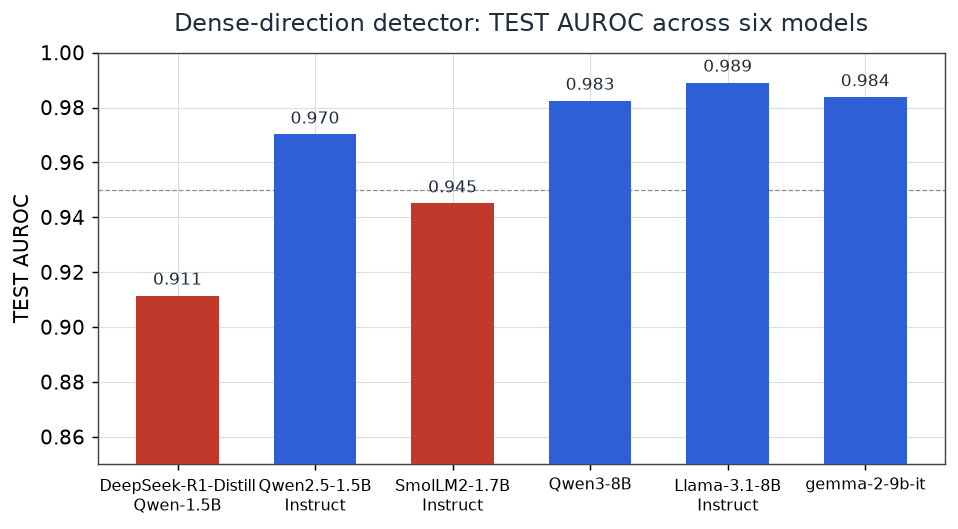

In [3]:
labels = [MODEL_LABELS[m] for m in MODEL_ORDER]
values = [auroc_by_model[m] for m in MODEL_ORDER]
colors = [PALETTE["vermilion"] if v < 0.95 else PALETTE["blue"] for v in values]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(labels, values, color=colors, width=0.6, zorder=3)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("TEST AUROC")
ax.set_title("Dense-direction detector: TEST AUROC across six models", color=PALETTE["ink"], pad=12)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=9.5, color=PALETTE["ink"])
ax.axhline(0.95, color=PALETTE["gray"], linewidth=0.7, linestyle="--", zorder=2)
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

**Reading:** four of six models cluster in a comparably strong 0.94-0.99 AUROC
band; DeepSeek and SmolLM2 (red) fall below it. Clean, in-distribution
detection is not fragile to model choice for most of this project's models -
the real spread shows up under adversarial paraphrase, below.

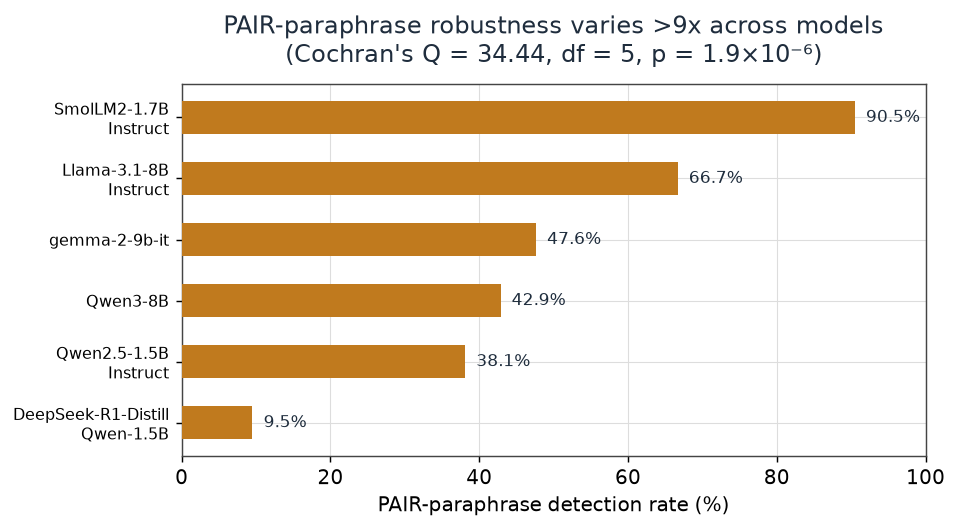

In [4]:
order = sorted(MODEL_ORDER, key=lambda m: pair_by_model[m])
labels_sorted = [MODEL_LABELS[m] for m in order]
rates_sorted = [pair_by_model[m] for m in order]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.barh(labels_sorted, rates_sorted, color=PALETTE["amber"], height=0.55, zorder=3)
ax.set_xlim(0, 100)
ax.set_xlabel("PAIR-paraphrase detection rate (%)")
ax.set_title(
    "PAIR-paraphrase robustness varies >9x across models\n"
    "(Cochran's Q = 34.44, df = 5, p = 1.9\u00d710\u207b\u2076)",
    color=PALETTE["ink"], pad=12,
)
for b, v in zip(bars, rates_sorted):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9.5, color=PALETTE["ink"])
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Reading:** SmolLM2 survives paraphrase 9.5x better than DeepSeek does
(90.5% vs. 9.5%). This spread is formally significant (Cochran's Q), not an
artifact of eyeballing six bars - and it is *not* explained by the same
factors that predict clean-prompt AUROC (DeepSeek is competitive on AUROC in
some conditions but collapses hardest under paraphrase). Part B asks what
mechanistic property might separate models that hold up from models that
don't.

## Part B -- Concentration vs. distribution: what makes a causal lever work

### SAE-feature suppression: dose-response curves

Ablating a model's causally-ranked SAE features one-by-one traces out how
concentrated the refusal mechanism is: does the *first* feature alone crash
refusal, or does it take many?

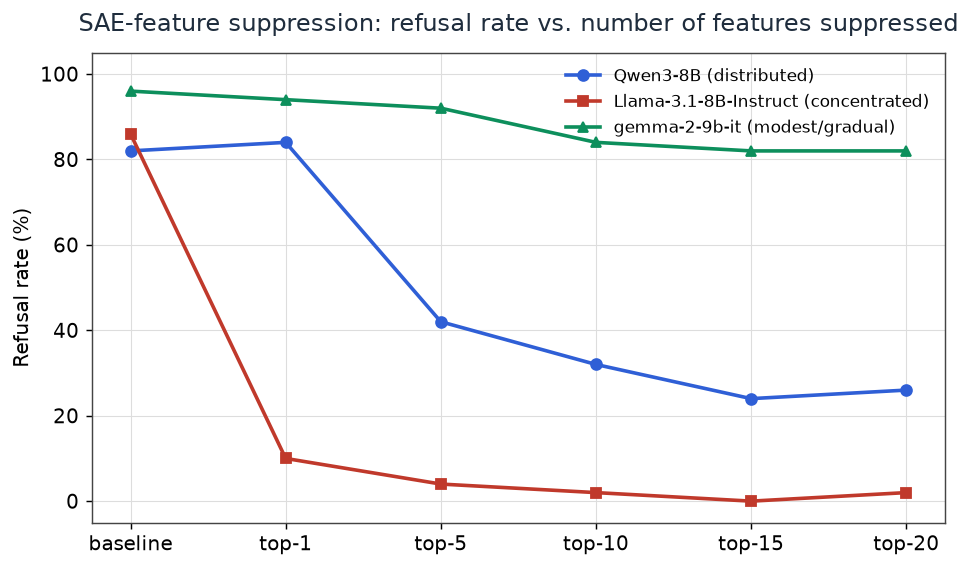

In [5]:
SAE_MODELS = {
    "Qwen3-8B": ("Qwen3-8B (distributed)", PALETTE["blue"], "o"),
    "Llama-3.1-8B-Instruct": ("Llama-3.1-8B-Instruct (concentrated)", PALETTE["vermilion"], "s"),
    "gemma-2-9b-it": ("gemma-2-9b-it (modest/gradual)", PALETTE["green"], "^"),
}
CONDITIONS = ["baseline", "top1", "top5", "top10", "top15", "top20"]
CONDITION_LABELS = ["baseline", "top-1", "top-5", "top-10", "top-15", "top-20"]

curves = {}
for model in SAE_MODELS:
    with open(RESULTS / f"sae_suppression_validation_{model}.json") as fh:
        d = json.load(fh)
    curves[model] = [d["results"][c]["refusal_stats"]["rate"] * 100 for c in CONDITIONS]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(CONDITIONS))
for model, (label, color, marker) in SAE_MODELS.items():
    ax.plot(x, curves[model], marker=marker, color=color, label=label, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(CONDITION_LABELS)
ax.set_ylabel("Refusal rate (%)")
ax.set_ylim(-5, 105)
ax.set_title("SAE-feature suppression: refusal rate vs. number of features suppressed", color=PALETTE["ink"], pad=12)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()

**Reading:** Llama's curve drops almost vertically at top-1 - one feature
carries nearly the whole causal effect. Qwen3-8B needs the full top-15 before
bottoming out - the effect is spread across many features, each contributing
a little. gemma sits in between: real but modest and gradual. This
concentration-vs-distribution axis turns out to predict something surprising
about the *dense direction* too, below.

### Isolating the causal lever: direction decomposition

Llama-3.1-8B-Instruct is this project's sharpest anomaly: the best passive
classifier (AUROC 0.989) of any model, yet its dense direction barely moves
refusal when ablated (92%->88%, not significant). Decomposing that direction
relative to its own top SAE feature's axis (formula above) isolates why.

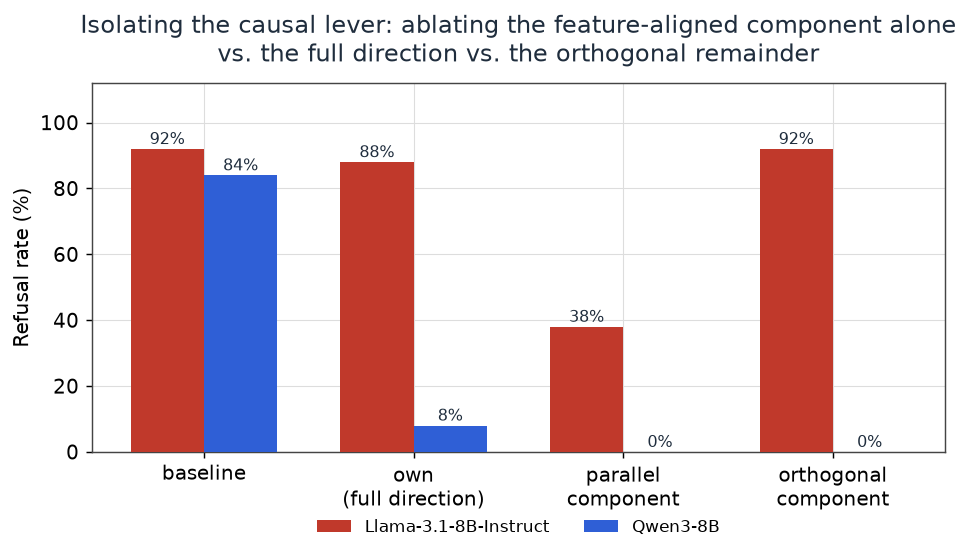

Llama-3.1-8B-Instruct: omnibus Cochran's Q=73.80, df=3, p=0.0000
Qwen3-8B: omnibus Cochran's Q=115.48, df=3, p=0.0000


In [6]:
with open(RESULTS / "llama_causal_gap_decomposition.json") as fh:
    decomp = json.load(fh)

DECOMP_CONDITIONS = ["baseline", "own_ablation", "parallel_ablation", "orthogonal_ablation"]
DECOMP_LABELS = ["baseline", "own\n(full direction)", "parallel\ncomponent", "orthogonal\ncomponent"]

llama_vals = [decomp["Llama-3.1-8B-Instruct"]["conditions"][c]["refusal_stats"]["rate"] * 100 for c in DECOMP_CONDITIONS]
qwen3_vals = [decomp["Qwen3-8B"]["conditions"][c]["refusal_stats"]["rate"] * 100 for c in DECOMP_CONDITIONS]

x = np.arange(len(DECOMP_CONDITIONS))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - width / 2, llama_vals, width, label="Llama-3.1-8B-Instruct", color=PALETTE["vermilion"], zorder=3)
b2 = ax.bar(x + width / 2, qwen3_vals, width, label="Qwen3-8B", color=PALETTE["blue"], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(DECOMP_LABELS)
ax.set_ylabel("Refusal rate (%)")
ax.set_ylim(0, 112)
ax.set_title(
    "Isolating the causal lever: ablating the feature-aligned component alone\n"
    "vs. the full direction vs. the orthogonal remainder",
    color=PALETTE["ink"], pad=12,
)
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1.5, f"{h:.0f}%", ha="center", fontsize=9, color=PALETTE["ink"])
ax.legend(frameon=False, fontsize=9.5, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
plt.tight_layout()
plt.show()

with open(RESULTS / "llama_causal_gap_decomposition.json") as fh:
    dd = json.load(fh)
for m in ("Llama-3.1-8B-Instruct", "Qwen3-8B"):
    q = dd[m]["significance"]["omnibus_cochrans_q"]
    print(f"{m}: omnibus Cochran's Q={q['q']:.2f}, df={q['df']}, p={q['p_value']:.4f}")

**Reading:** for Llama, the isolated feature-aligned axis alone (92%->38%)
outperforms ablating the *entire* dense direction (92%->88%) - the direction's
own 98%-of-magnitude orthogonal remainder does nothing at all (92%->92%,
identical to baseline). The dense direction is a weak causal lever precisely
*because* it is dominated by norm from a causally-inert axis, diluting a real
effect that lives narrowly along the SAE feature's own direction. Qwen3-8B
shows no such asymmetry - both components independently crash refusal,
consistent with its distributed suppression curve above. Concentration versus
distribution is the same property showing up in two independent measurements
(SAE suppression, direction decomposition) for the same two models.

## Part C -- Content or framing? The wrapper-swap mechanism

### Variance decomposition, replicated design

A separate mechanistic question: does a model's dominant SAE feature track a
harmful request's *content*, or the surface *framing* used to disguise it?
A controlled 10-core-request x 4-wrapper-category x 3-phrasing-replicate
factorial (`wrapper_swap_replication.py`) answers this with a real,
replicated design - letting the core x category interaction be tested
directly instead of left as an unexaminable residual.

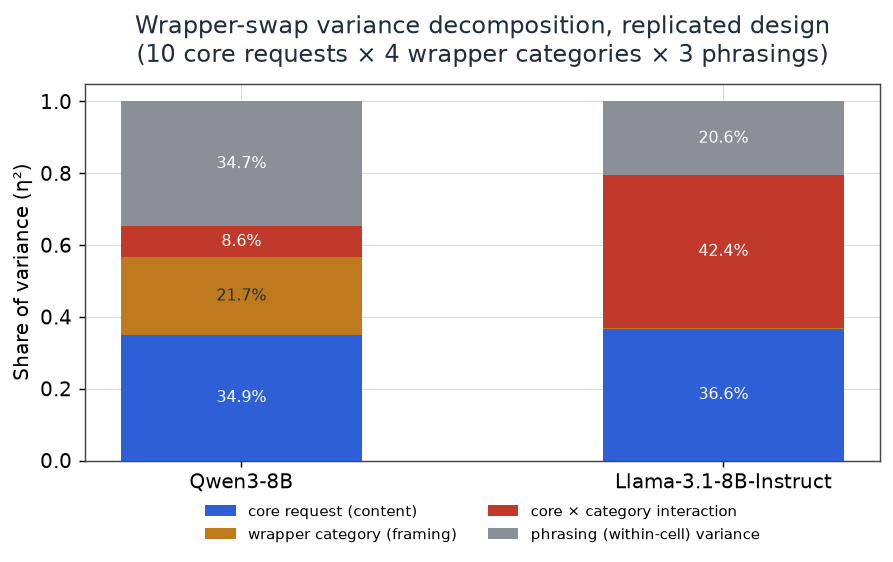

Qwen3-8B: interaction F=0.737 p_Ftest=0.8131 p_permutation=0.6800
Llama-3.1-8B-Instruct: interaction F=6.114 p_Ftest=0.0000 p_permutation=0.0001


In [7]:
with open(RESULTS / "wrapper_swap_replication.json") as fh:
    wrapper = json.load(fh)

labels = ["Qwen3-8B", "Llama-3.1-8B-Instruct"]
components = [
    ("eta_sq_core", PALETTE["blue"], "core request (content)"),
    ("eta_sq_category", PALETTE["amber"], "wrapper category (framing)"),
    ("eta_sq_interaction", PALETTE["vermilion"], "core \u00d7 category interaction"),
    ("eta_sq_residual", PALETTE["gray"], "phrasing (within-cell) variance"),
]

fig, ax = plt.subplots(figsize=(7.0, 4.5))
bottoms = np.zeros(2)
for key, color, name in components:
    vals = [wrapper["Qwen3-8B"]["stats"][key], wrapper["Llama-3.1-8B-Instruct"]["stats"][key]]
    ax.bar(labels, vals, bottom=bottoms, color=color, label=name, width=0.5, zorder=3)
    for i, v in enumerate(vals):
        if v > 0.03:
            ax.text(i, bottoms[i] + v / 2, f"{v*100:.1f}%", ha="center", va="center",
                     fontsize=9, color="white" if color != PALETTE["amber"] else PALETTE["ink"])
    bottoms += np.array(vals)

ax.set_ylabel("Share of variance (\u03b7\u00b2)")
ax.set_ylim(0, 1.05)
ax.set_title(
    "Wrapper-swap variance decomposition, replicated design\n"
    "(10 core requests \u00d7 4 wrapper categories \u00d7 3 phrasings)",
    color=PALETTE["ink"], pad=12,
)
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.tight_layout()
plt.show()

for m in labels:
    s = wrapper[m]["stats"]
    print(f"{m}: interaction F={s['f_interaction']:.3f} p_Ftest={s['p_interaction_Ftest']:.4f} "
          f"p_permutation={s['p_interaction_permutation']:.4f}")

**Reading:** Qwen3-8B's core and category effects are additive - both matter
independently (p<0.0001 each) but the interaction is not significant by
either the classical F-test or the independent Freedman-Lane permutation
check (p=0.81 / p=0.68). Llama shows the opposite pattern: a real,
statistically confirmed core x category interaction (42.4% of variance,
p<0.0001 by both tests) - the effect of framing on Llama's feature genuinely
depends on which request it's paired with. This resolves what the original
(non-replicated) design left as an unexaminable 56.4% residual: substantially
real interaction, not primarily phrasing noise. A separate, incidental
finding falls out too - Qwen3-8B's within-cell phrasing variance is large
(34.7%), meaning this model's feature is sensitive to specific wording even
within a fixed framing category.

## Conclusions & Interpretation

**Detection is real and consistent; robustness to paraphrase is not.** Four
of six models cluster in a strong 0.94-0.99 AUROC band on clean prompts, but
PAIR-paraphrase detection spans 9.5%-90.5% (Cochran's Q p=1.9x10^-6) - a
real, formally significant spread this project traces mechanistically rather
than just reporting as a fact.

**The spread is explained by how concentrated each model's causal mechanism
is, not by an unrelated property.** SAE-feature suppression curves show
Llama's effect concentrated in one feature and Qwen3-8B's spread across many;
the same concentration/distribution split shows up independently in the
dense-direction decomposition (Llama's isolated feature-aligned axis
outperforms its full direction; Qwen3-8B's two components are both
independently sufficient). Two different measurements, same underlying
property, on the same two models - not one number dressed up as two
findings.

**Llama's best-classifier / weakest-causal-mechanism anomaly is now
explained, not just documented.** The dense direction is a weak causal lever
specifically because 98% of its magnitude sits on an axis with zero causal
effect on its own - it correlates well enough with the refusal label to
classify accurately, without being a good causal handle on the mechanism
that actually produces refusal.

**Content vs. framing is a real, model-specific property, confirmed with a
properly replicated design.** Qwen3-8B's dominant feature tracks surface
framing; Llama's tracks the request's content - and, now that real
replication exists, Llama's effect includes a genuine, independently-
confirmed core-by-category interaction, not just noise inherited from an
under-powered original design.

**Caveat, stated plainly.** All of this is correlational-to-mechanistic
evidence from two models (Llama, Qwen3-8B) examined in this much depth; the
concentration/distribution account is a coherent, multiply-corroborated
reading of this project's own data, not a proven general theory of why some
models' refusal mechanisms take this geometric shape and others don't -
see `reports/DECISIONS.md` and `reports/RESULTS.md` for the full account,
including what remains genuinely open.